<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


<h1><center>Patient Segmentation</center></h1>


# Data Description

The target dataset was retrieved from Kaggle at https://www.kaggle.com/datasets/nudratabbas/patient-segmentation-data.

## Content

This dataset contains 2,000 patient records with comprehensive information including:

- Demographics: Age, Gender, Geographic location (State, City)
- Health Metrics: Height, Weight, BMI (Body Mass Index), Number of chronic conditions, Primary medical condition
- Healthcare Utilization: Annual visit frequency, Days since last visit, Average billing amount per visit
- Insurance & Engagement: Insurance type (Medicare, Medicaid, Private, Self-Pay), Preventive care participation flag

## Objective

This dataset enables healthcare marketers and analysts to segment patients into meaningful groups based on their demographics, health conditions, insurance types, and healthcare utilization patterns.

Clustering methods, supported by dimensionality reduction approaches, will be applied, evaluated and compared to achieve a meaningful patient segmentation strategy.

# Data import and overview

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('data/patient_segmentation_dataset.csv')

display(data.head())

,PatientID,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
0,P10000,64,Male,GA,Unknown,151,115,50.4,Private,Arthritis,3,7,2995.0,2025-07-18,186,0
1,P10001,59,Male,OH,Unknown,189,68,19.0,Medicare,Depression,1,8,1209.0,2025-12-12,39,0
2,P10002,58,Female,PA,Unknown,156,91,37.4,Private,Asthma,1,4,999.0,2025-09-16,126,0
3,P10003,43,Female,GA,Unknown,152,92,39.8,Medicare,Hypertension,1,6,5638.5,2025-04-09,286,1
4,P10004,53,Female,NC,Unknown,167,51,18.3,Medicaid,Asthma,1,4,5796.0,2025-03-07,319,0


In [3]:
data.shape

(2000, 16)

## Features description

In [4]:
list(data.columns)

['PatientID',
 'Age',
 'Gender',
 'State',
 'City',
 'Height_cm',
 'Weight_kg',
 'BMI',
 'Insurance_Type',
 'Primary_Condition',
 'Num_Chronic_Conditions',
 'Annual_Visits',
 'Avg_Billing_Amount',
 'Last_Visit_Date',
 'Days_Since_Last_Visit',
 'Preventive_Care_Flag']

In [5]:
data.dtypes.value_counts().to_frame()

,count
str,7
int64,7
float64,2


In [6]:
numerical_data = data.select_dtypes(include='number')

numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2000.0,50.69550,15.444450,18.0,40.0,51.00,63.250,87.0
Height_cm,2000.0,167.90750,12.684494,145.0,158.0,168.00,177.000,195.0
Weight_kg,2000.0,85.14350,20.385428,50.0,67.0,86.00,103.000,120.0
BMI,2000.0,30.74065,8.839952,13.4,23.8,30.10,37.025,57.1
Num_Chronic_Conditions,2000.0,1.08000,0.890504,0.0,1.0,1.00,1.000,3.0
Annual_Visits,2000.0,5.46650,3.485965,1.0,3.0,4.00,8.000,12.0
Avg_Billing_Amount,2000.0,4000.27050,2463.239215,207.0,2061.0,3707.25,5650.875,12467.5
Days_Since_Last_Visit,2000.0,180.08500,104.688484,1.0,90.0,183.00,268.000,365.0
Preventive_Care_Flag,2000.0,0.46400,0.498827,0.0,0.0,0.00,1.000,1.0


In [7]:
categorical_data = data.select_dtypes(include='str')

categorical_data.describe()

,PatientID,Gender,State,City,Insurance_Type,Primary_Condition,Last_Visit_Date
count,2000,2000,2000,2000,2000,1505,2000
unique,2000,2,10,20,4,9,364
top,P10000,Female,NC,Unknown,Medicare,Hypertension,2025-11-27
freq,1,1001,213,1012,906,210,13


# EDA

## Check ID uniqueness

In [8]:
data.shape[0] == len(data['PatientID'].unique())

True

There are no duplicated samples.

## Handle missing data

In [9]:
data.isnull().sum().to_frame(name='Missing Values Count')

,Missing Values Count
PatientID,0
Age,0
Gender,0
State,0
City,0
Height_cm,0
Weight_kg,0
BMI,0
Insurance_Type,0
Primary_Condition,495


The `Primary_Condition` feature is the only one characterized by missing values, in particular ~25% of the total.

In [10]:
data['Primary_Condition'].value_counts().to_frame()

,count
Primary_Condition,
Hypertension,210
Obesity,183
Anxiety,175
Arthritis,163
Depression,160
Asthma,160
Diabetes,158
Heart Disease,150
COPD,146


Missing data in this case can be interpreted as the absence of a primary condition: missing values will be interpreted in this sense by applying `None` as filling value.

In [11]:
data['Primary_Condition'] = data['Primary_Condition'].fillna('None')

## Features distribution

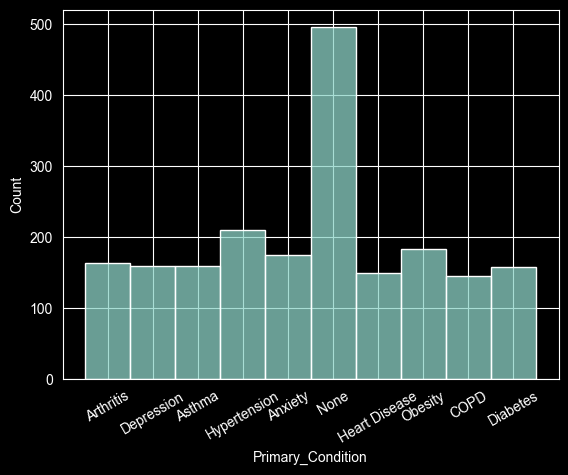

In [12]:
sns.histplot(data['Primary_Condition'])
plt.xticks(rotation=30);

In [13]:
data['Insurance_Type'].value_counts().to_frame()

,count
Insurance_Type,
Medicare,906
Private,545
Medicaid,483
Self-Pay,66


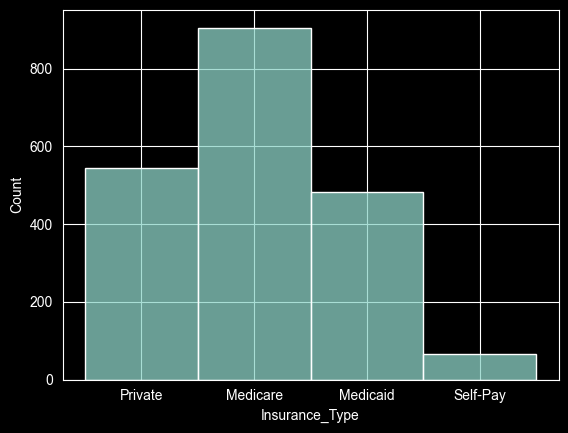

In [14]:
sns.histplot(data['Insurance_Type']);

- Medicare is federal health insurance for people 65 or older, and some people under 65 with certain disabilities or conditions.
- Medicaid is a joint federal and state program that helps cover medical costs for some people with limited income and resources. Medicaid offers benefits that Medicare doesn’t normally cover, like nursing home care and personal care services.

Source - https://www.hhs.gov/answers/medicare-and-medicaid/what-is-the-difference-between-medicare-medicaid/index.html

## BMI Features Analysis

BMI is calculated from height and weight: let's check their correlations and data correctness.

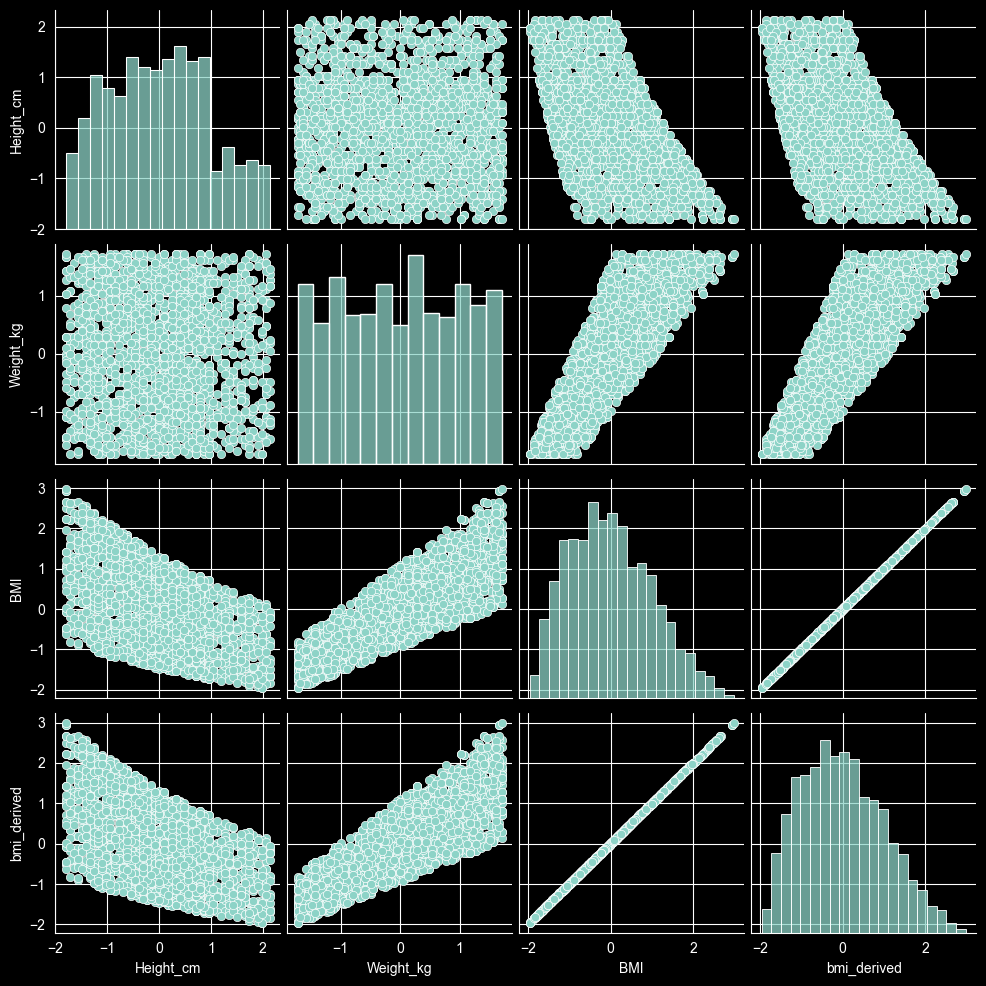

In [15]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

bmi_columns = ['Height_cm', 'Weight_kg', 'BMI']
data_bmi = data[bmi_columns]
data_bmi['bmi_derived'] = data_bmi['Weight_kg'] / data_bmi['Height_cm'] ** 2
data_bmi = pd.DataFrame(StandardScaler().fit_transform(data_bmi), columns=data_bmi.columns)
sns.pairplot(data_bmi);

We can observe perfect correlation between `BMI` and `bmi_derived` - we can confirm `BMI` as a linear combination of `Height_cm` and `Weight_kg`.

## Data Correlations

,Pearson Correlation Value,Correlating Feature
Age,0.797068,Num_Chronic_Conditions
Height_cm,0.535225,BMI
Weight_kg,0.842057,BMI
BMI,0.842057,Weight_kg
Num_Chronic_Conditions,0.797068,Age
Annual_Visits,0.366565,Age
Avg_Billing_Amount,0.425172,Num_Chronic_Conditions
Days_Since_Last_Visit,0.032195,Height_cm
Preventive_Care_Flag,0.118994,Age


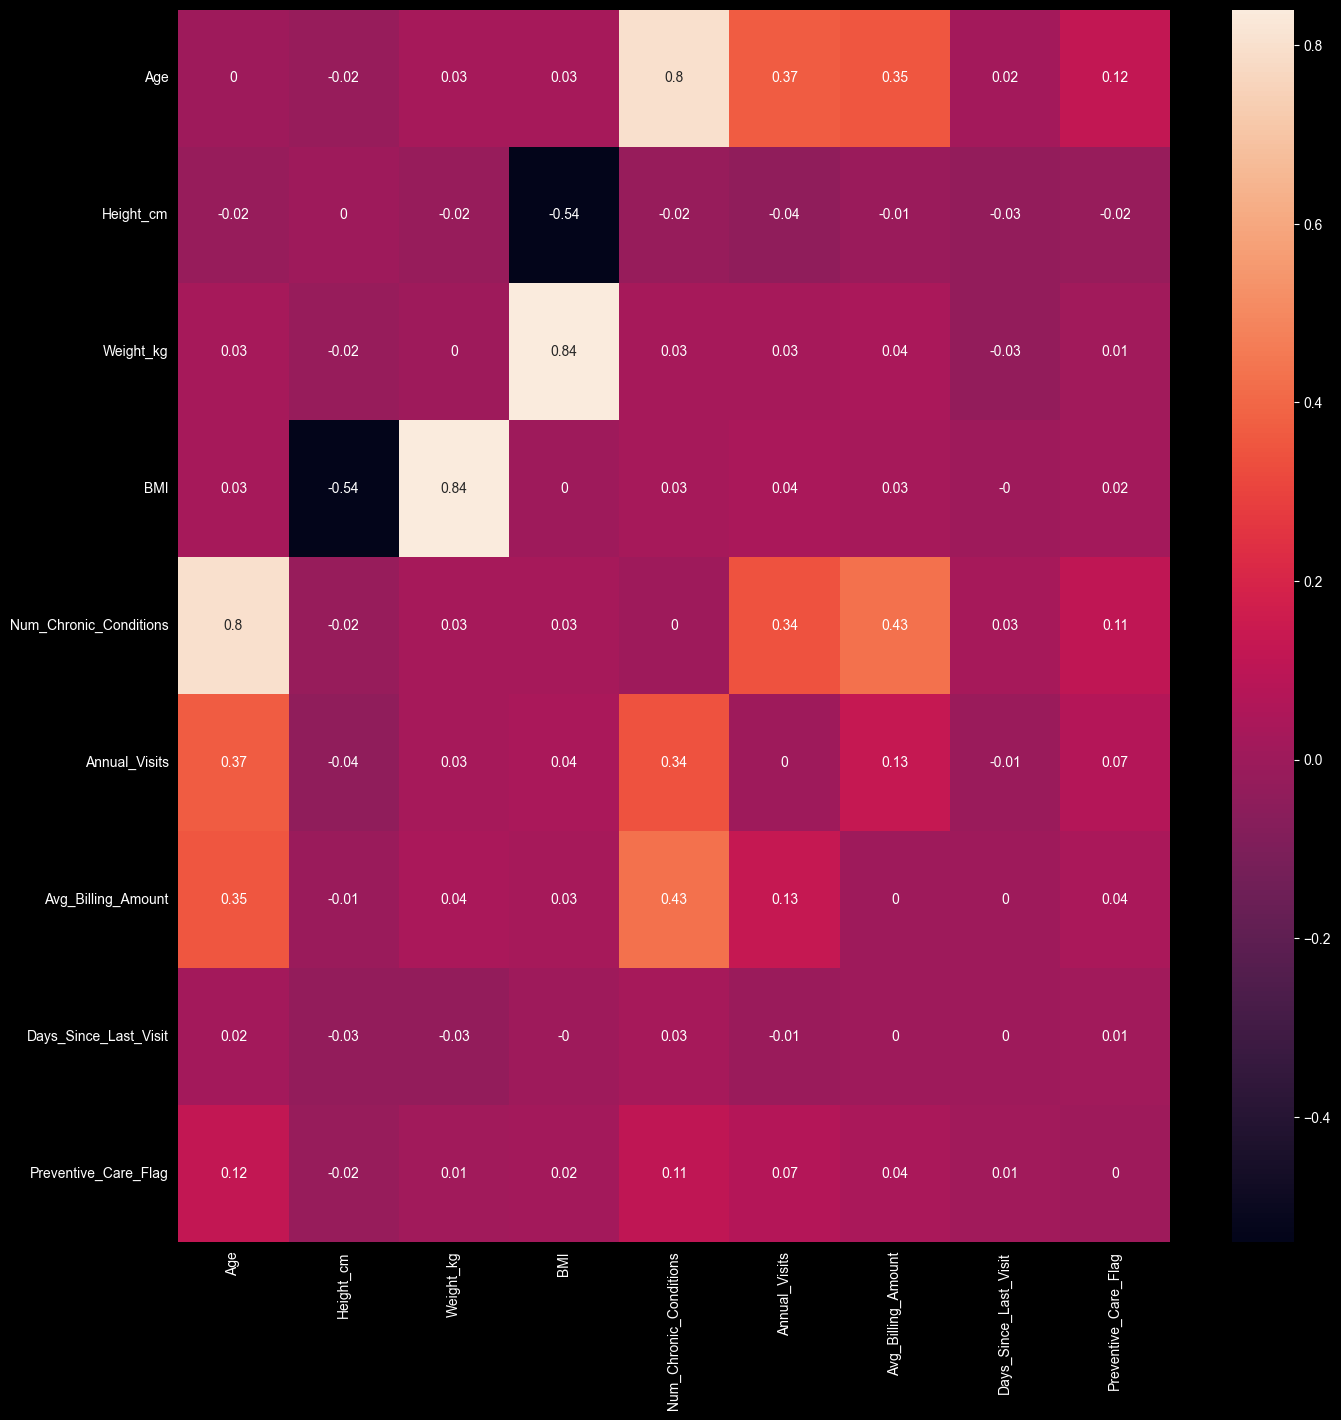

In [16]:
corr_mat = numerical_data.corr()

for col in numerical_data.columns:
    corr_mat.loc[col, col] = 0.0

fig, ax = plt.subplots(figsize=(16, 16))
sns.heatmap(round(corr_mat, 2), annot=True);

maximal_correlations = pd.concat([corr_mat.abs().max(), corr_mat.abs().idxmax()], axis=1).rename(columns={0: 'Pearson Correlation Value', 1: 'Correlating Feature'})
display(maximal_correlations)

Age resulted being strongly correlated with the number of chronic conditions. Other significant correlations are given by the pairs (`Annual_Visits`, `Age`) and (`Avg_Billing_Amount`, `Num_Chronic_Conditions`). These correlations pave the path to meaningful clusterings.

## Data Cleaning

I'll drop the following columns:
- `PatientID` - we used it to check ID uniqueness, now it's not needed anymore.
- `State`, `City` - in this particular study we are not interested in segmentation by location.
- `Last_Visit_Date` - directly correlated with `Days_Since_Last_Visit`.
- `Height_cm`, `Weight_kg` - directly correlated with `BMI`.

In [17]:
data.drop(columns=['PatientID', 'State', 'City', 'Last_Visit_Date', 'Height_cm', 'Weight_kg'], inplace=True)

In [18]:
categorical_data = data.select_dtypes(include='str')

categorical_data

,Gender,Insurance_Type,Primary_Condition
0,Male,Private,Arthritis
1,Male,Medicare,Depression
2,Female,Private,Asthma
3,Female,Medicare,Hypertension
4,Female,Medicaid,Asthma
...,...,...,...
1995,Male,Medicaid,None
1996,Female,Private,None
1997,Female,Private,Anxiety
1998,Female,Medicare,Heart Disease


## Features Encoding

### One-Hot Encoding of Categorical Features

In [19]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

one_hot = ColumnTransformer(transformers=[
	("one_hot", OneHotEncoder(drop='first'), categorical_data.columns)    # drop first to prevent multicollinearity
],remainder="passthrough")
one_hot_data = one_hot.fit_transform(data)
data_1 = pd.DataFrame(data=one_hot_data,columns=one_hot.get_feature_names_out())
data_1.rename(columns=lambda c: c.split('__')[1], inplace=True)

data_1

,Gender_Male,Insurance_Type_Medicare,Insurance_Type_Private,Insurance_Type_Self-Pay,Primary_Condition_Arthritis,Primary_Condition_Asthma,Primary_Condition_COPD,Primary_Condition_Depression,Primary_Condition_Diabetes,Primary_Condition_Heart Disease,Primary_Condition_Hypertension,Primary_Condition_None,Primary_Condition_Obesity,Age,BMI,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Preventive_Care_Flag
0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64.0,50.4,3.0,7.0,2995.0,186.0,0.0
1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,59.0,19.0,1.0,8.0,1209.0,39.0,0.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,58.0,37.4,1.0,4.0,999.0,126.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,43.0,39.8,1.0,6.0,5638.5,286.0,1.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,18.3,1.0,4.0,5796.0,319.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,37.0,28.7,0.0,4.0,4581.0,122.0,1.0
1996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,32.0,41.2,0.0,1.0,329.0,150.0,1.0
1997,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,51.8,1.0,8.0,4942.5,242.0,1.0
1998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,74.0,35.6,3.0,7.0,4700.0,195.0,1.0


### Scaling of Numerical Features

Scaling is required for a proper application of PCA and clustering methods based on distance metrics sensitive to scaling.

In [20]:
numerical_data = data.select_dtypes(include='number')
float_data = numerical_data.drop('Preventive_Care_Flag', axis=1)

data_1[float_data.columns] = MinMaxScaler().fit_transform(data_1[float_data.columns])

data_1

,Gender_Male,Insurance_Type_Medicare,Insurance_Type_Private,Insurance_Type_Self-Pay,Primary_Condition_Arthritis,Primary_Condition_Asthma,Primary_Condition_COPD,Primary_Condition_Depression,Primary_Condition_Diabetes,Primary_Condition_Heart Disease,Primary_Condition_Hypertension,Primary_Condition_None,Primary_Condition_Obesity,Age,BMI,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Preventive_Care_Flag
0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.846682,1.000000,0.545455,0.227397,0.508242,0.0
1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.594203,0.128146,0.333333,0.636364,0.081726,0.104396,0.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.579710,0.549199,0.333333,0.272727,0.064598,0.343407,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.362319,0.604119,0.333333,0.454545,0.443008,0.782967,1.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.507246,0.112128,0.333333,0.272727,0.455854,0.873626,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.275362,0.350114,0.000000,0.272727,0.356755,0.332418,1.0
1996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.202899,0.636156,0.000000,0.000000,0.009951,0.409341,1.0
1997,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.463768,0.878719,0.333333,0.636364,0.386240,0.662088,1.0
1998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.811594,0.508009,1.000000,0.545455,0.366461,0.532967,1.0


# Modeling

## Dimensionality Reduction with Principal Component Analysis

Let us apply PCA to reduce dimensionality prior to clustering by keeping 95% of the variance.

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
data_2 = pca.fit_transform(data_1)

data_2

array([[-0.25413266,  0.32663535,  0.73138055, ..., -0.04300871,
         0.17726814,  0.55138052],
       [ 0.46962932, -0.64367937,  0.39849257, ...,  0.15265416,
        -0.20491267, -0.32145258],
       [-0.4846978 ,  0.48154565, -0.26413939, ..., -0.41240981,
        -0.27830761, -0.01846886],
       ...,
       [-0.28454947,  1.1175692 , -0.17672028, ...,  0.15050833,
        -0.04651007,  0.43971424],
       [ 1.01829503,  0.36131512, -0.33670574, ...,  0.27730886,
         0.229737  ,  0.13306059],
       [-0.60639328,  0.10940043,  0.63844022, ..., -0.33132709,
        -0.18563971, -0.01592598]], shape=(2000, 16))

In [22]:
data_2.shape

(2000, 16)

Data was reduced from 20 to 16 features.

## Clustering Method #1 - KMeans

### Elbow curve for `n_clusters` determination

KMeans requires the setting of `n_clusters` parameter. Let's apply the Elbow method to understand which could be the optimal n_clusters, based on how the inertia metric varies with the number of clusters.

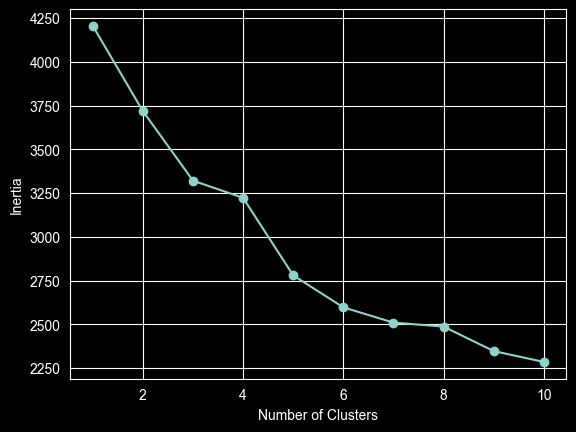

In [23]:
from sklearn.cluster import KMeans

inertia = []
list_num_clusters = list(range(1,11))

for num_clusters in list_num_clusters:
    km = KMeans(n_clusters=num_clusters, init='k-means++', random_state=42)
    km.fit(data_2)
    inertia.append(km.inertia_)

plt.plot(list_num_clusters,inertia)
plt.scatter(list_num_clusters,inertia)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia');

A strong inflection point (elbow) is noticeable at #clusters = 3: let's proceed with this configuration.

In [24]:
chosen_n_clusters = 3

In [25]:
km = KMeans(n_clusters=chosen_n_clusters, init='k-means++', random_state=42)
clusters = km.fit_predict(data_2)

clusters

array([2, 1, 2, ..., 2, 0, 2], shape=(2000,), dtype=int32)

In [26]:
data_clu = pd.concat([data, pd.Series(clusters, name='cluster')], axis=1)

data_clu

,Age,Gender,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Preventive_Care_Flag,cluster
0,64,Male,50.4,Private,Arthritis,3,7,2995.0,186,0,2
1,59,Male,19.0,Medicare,Depression,1,8,1209.0,39,0,1
2,58,Female,37.4,Private,Asthma,1,4,999.0,126,0,2
3,43,Female,39.8,Medicare,Hypertension,1,6,5638.5,286,1,0
4,53,Female,18.3,Medicaid,Asthma,1,4,5796.0,319,0,2
...,...,...,...,...,...,...,...,...,...,...,...
1995,37,Male,28.7,Medicaid,None,0,4,4581.0,122,1,2
1996,32,Female,41.2,Private,None,0,1,329.0,150,1,2
1997,50,Female,51.8,Private,Anxiety,1,8,4942.5,242,1,2
1998,74,Female,35.6,Medicare,Heart Disease,3,7,4700.0,195,1,0


### Clustering Analysis

In [27]:
non_categorical_columns = list(set(data.columns) - set(categorical_data.columns) - {'Preventive_Care_Flag'})

display(data_clu.groupby('cluster')['cluster'].count().to_frame())
display(data_clu.groupby('cluster')[non_categorical_columns].describe().T)
display(data_clu.groupby('cluster')['Insurance_Type'].value_counts(normalize=True).to_frame())
display(data_clu.groupby('cluster')['Primary_Condition'].value_counts(normalize=True).to_frame())
display(data_clu.groupby('cluster')['Preventive_Care_Flag'].value_counts(normalize=True).to_frame())

,cluster
cluster,
0,312
1,838
2,850


cluster                                  0             1             2
Age                    count    312.000000    838.000000    850.000000
                       mean      59.128205     57.372315     41.017647
                       std       12.291067     13.251354     13.010313
                       min       30.000000     30.000000     18.000000
                       25%       49.000000     46.000000     30.000000
                       50%       60.000000     58.000000     41.000000
                       75%       69.000000     69.000000     51.000000
                       max       87.000000     85.000000     64.000000
Annual_Visits          count    312.000000    838.000000    850.000000
                       mean       6.435897      5.896181      4.687059
                       std        3.548795      3.463406      3.322259
                       min        1.000000      1.000000      1.000000
                       25%        3.000000      3.000000      2.000000
                       50%        6.000000      6.000000      4.000000
                       75%        9.000000      9.000000      7.000000
                       max       12.000000     12.000000     12.000000
BMI                    count    312.000000    838.000000    850.000000
                       mean      32.831410     30.003580     30.699882
                       std        9.012591      8.633689      8.866159
                       min       15.400000     13.400000     13.400000
                       25%       25.575000     23.225000     23.525000
                       50%       32.650000     29.050000     30.100000
                       75%       39.400000     35.600000     37.100000
                       max       56.600000     53.200000     57.100000
Avg_Billing_Amount     count    312.000000    838.000000    850.000000
                       mean    4548.450321   4387.877088   3416.921765
                       std     2799.755499   2627.159028   2002.754546
                       min      316.500000    207.000000    224.000000
                       25%     2377.125000   2256.250000   1796.250000
                       50%     4305.000000   4061.250000   3322.500000
                       75%     6292.500000   6231.750000   4714.250000
                       max    12350.000000  12467.500000  11805.000000
Days_Since_Last_Visit  count    312.000000    838.000000    850.000000
                       mean     183.480769    177.511933    181.375294
                       std      105.931390    105.750294    103.232144
                       min        2.000000      1.000000      1.000000
                       25%       91.500000     88.000000     91.000000
                       50%      190.500000    176.000000    186.000000
                       75%      277.750000    262.750000    266.000000
                       max      360.000000    365.000000    365.000000
Num_Chronic_Conditions count    312.000000    838.000000    850.000000
                       mean       1.509615      1.385442      0.621176
                       std        0.859917      0.884286      0.674296
                       min        0.000000      0.000000      0.000000
                       25%        1.000000      1.000000      0.000000
                       50%        1.000000      1.000000      1.000000
                       75%        2.000000      2.000000      1.000000
                       max        3.000000      3.000000      3.000000

proportion
cluster Insurance_Type            
0       Medicare          0.759615
        Medicaid          0.233974
        Private           0.006410
1       Medicare          0.798329
        Medicaid          0.201671
2       Private           0.638824
        Medicaid          0.283529
        Self-Pay          0.077647

proportion
cluster Primary_Condition            
0       Anxiety              0.137821
        Obesity              0.134615
        Hypertension         0.125000
        Arthritis            0.125000
        Asthma               0.092949
        Diabetes             0.092949
        COPD                 0.089744
        Depression           0.089744
        Heart Disease        0.073718
        None                 0.038462
1       Hypertension         0.124105
        None                 0.106205
        Obesity              0.103819
        Heart Disease        0.101432
        Asthma               0.097852
        Anxiety              0.096659
        COPD                 0.096659
        Depression           0.095465
        Diabetes             0.094272
        Arthritis            0.083532
2       None                 0.463529
        Hypertension         0.078824
        Arthritis            0.063529
        Obesity              0.063529
        Depression           0.061176
        Anxiety              0.060000
        Diabetes             0.058824
        Asthma               0.057647
        Heart Disease        0.049412
        COPD                 0.043529

proportion
cluster Preventive_Care_Flag            
0       1                       1.000000
1       0                       0.653938
        1                       0.346062
2       0                       0.616471
        1                       0.383529

The resulting 3 clusters can be defined with the following characteristics:

0. High-Risk Seniors - 15% of the total, highest average age (59 years), with all of them being in preventive care.
1. Low-Risk Seniors - 42% of the total, lower-risk diseases, with most of them not being in preventive care; all seniors with no primary conditions are included.
2. Young Adults - 43% of the total, average age of 42 years, lowest billing amount, with most of them having private insurance; few of them have chronic conditions.

## Clustering Method #2 - Hierarchical Agglomerative Clustering

In [28]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=chosen_n_clusters, metric='euclidean', linkage='ward')
clusters = agg.fit_predict(data_2)

In [29]:
data_clu = pd.concat([data, pd.Series(clusters, name='cluster')], axis=1)

data_clu

,Age,Gender,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Preventive_Care_Flag,cluster
0,64,Male,50.4,Private,Arthritis,3,7,2995.0,186,0,2
1,59,Male,19.0,Medicare,Depression,1,8,1209.0,39,0,0
2,58,Female,37.4,Private,Asthma,1,4,999.0,126,0,0
3,43,Female,39.8,Medicare,Hypertension,1,6,5638.5,286,1,0
4,53,Female,18.3,Medicaid,Asthma,1,4,5796.0,319,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1995,37,Male,28.7,Medicaid,None,0,4,4581.0,122,1,1
1996,32,Female,41.2,Private,None,0,1,329.0,150,1,1
1997,50,Female,51.8,Private,Anxiety,1,8,4942.5,242,1,2
1998,74,Female,35.6,Medicare,Heart Disease,3,7,4700.0,195,1,0


In [30]:
display(data_clu.groupby('cluster')['cluster'].count().to_frame())
display(data_clu.groupby('cluster')[non_categorical_columns].describe().T)
display(data_clu.groupby('cluster')['Insurance_Type'].value_counts(normalize=True).to_frame())
display(data_clu.groupby('cluster')['Primary_Condition'].value_counts(normalize=True).to_frame())
display(data_clu.groupby('cluster')['Preventive_Care_Flag'].value_counts(normalize=True).to_frame())

,cluster
cluster,
0,996
1,495
2,509


cluster                                  0            1             2
Age                    count    996.000000   495.000000    509.000000
                       mean      60.112450    30.402020     52.003929
                       std       11.598016     6.393158      7.651616
                       min       40.000000    18.000000     40.000000
                       25%       50.000000    26.000000     45.000000
                       50%       62.000000    32.000000     51.000000
                       75%       69.000000    36.000000     58.000000
                       max       87.000000    39.000000     76.000000
Annual_Visits          count    996.000000   495.000000    509.000000
                       mean       6.318273     2.511111      6.673870
                       std        3.431762     1.092567      3.492360
                       min        1.000000     1.000000      1.000000
                       25%        3.000000     2.000000      4.000000
                       50%        6.000000     3.000000      7.000000
                       75%        9.000000     3.000000     10.000000
                       max       12.000000     4.000000     12.000000
BMI                    count    996.000000   495.000000    509.000000
                       mean      31.224297    29.886263     30.625147
                       std        8.923273     8.828389      8.635328
                       min       13.400000    13.600000     13.400000
                       25%       24.600000    22.800000     23.800000
                       50%       30.500000    29.400000     29.800000
                       75%       37.200000    35.500000     37.100000
                       max       56.600000    57.100000     54.200000
Avg_Billing_Amount     count    996.000000   495.000000    509.000000
                       mean    4632.298695  2598.311111   4126.930255
                       std     2698.275664  1393.221546   2239.106317
                       min      313.500000   207.000000    306.000000
                       25%     2548.500000  1449.000000   2323.500000
                       50%     4494.750000  2666.000000   4156.500000
                       75%     6418.125000  3765.500000   5910.000000
                       max    12467.500000  4992.000000  11805.000000
Days_Since_Last_Visit  count    996.000000   495.000000    509.000000
                       mean     182.217871   173.494949    182.320236
                       std      104.779979   103.657132    105.441935
                       min        1.000000     1.000000      1.000000
                       25%       94.000000    82.000000     88.000000
                       50%      183.000000   170.000000    190.000000
                       75%      271.000000   252.000000    271.000000
                       max      365.000000   365.000000    364.000000
Num_Chronic_Conditions count    996.000000   495.000000    509.000000
                       mean       1.554217     0.000000      1.202358
                       std        0.797025     0.000000      0.532704
                       min        1.000000     0.000000      1.000000
                       25%        1.000000     0.000000      1.000000
                       50%        1.000000     0.000000      1.000000
                       75%        2.000000     0.000000      1.000000
                       max        3.000000     0.000000      3.000000

proportion
cluster Insurance_Type            
0       Medicare          0.788153
        Medicaid          0.147590
        Private           0.064257
1       Medicaid          0.343434
        Private           0.319192
        Medicare          0.204040
        Self-Pay          0.133333
2       Private           0.634578
        Medicaid          0.326130
        Medicare          0.039293

proportion
cluster Primary_Condition            
0       Asthma               0.160643
        Arthritis            0.141566
        Anxiety              0.118474
        Hypertension         0.116466
        Heart Disease        0.113454
        COPD                 0.108434
        Obesity              0.107430
        Diabetes             0.080321
        Depression           0.053213
1       None                 1.000000
2       Depression           0.210216
        Hypertension         0.184676
        Diabetes             0.153242
        Obesity              0.149312
        Anxiety              0.111984
        COPD                 0.074656
        Heart Disease        0.072692
        Arthritis            0.043222

proportion
cluster Preventive_Care_Flag            
0       1                       0.502008
        0                       0.497992
1       0                       0.650505
        1                       0.349495
2       1                       0.500982
        0                       0.499018

The resulting 3 clusters can be defined with the following characteristics:

0. High-Risk Seniors - 50% of the total, highest average age (60 years), with the highest number of chronic conditions; they include the majority of patients in preventive care; mostly characterized by high-risk diseases.
1. Healthy Young Adults - 24% of the total, average age of 30 years, characterized by no chronic nor primary conditions.
2. Low-Risk Seniors - 26% of the total, average age of 52 years, with most of them having private insurance; mostly characterized by low-risk diseases.


### Dendrogram plot from Agglomerative Clustering

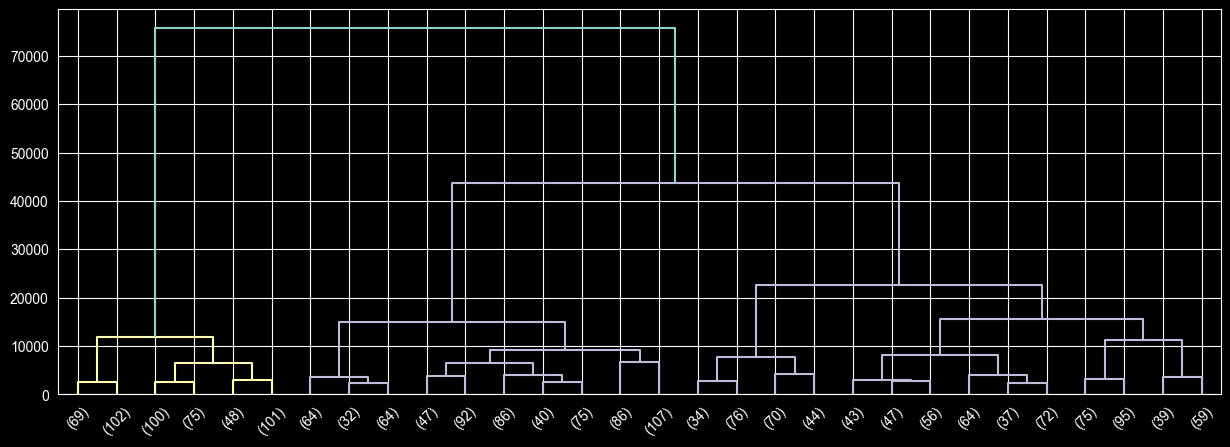

In [31]:
from scipy.cluster import hierarchy

Z = hierarchy.linkage(agg.children_, method='ward')

fig, ax = plt.subplots(figsize=(15,5))
den = hierarchy.dendrogram(Z, orientation='top', p=30, truncate_mode='lastp', show_leaf_counts=True, ax=ax)

## Clustering Method #3 - Mean Shift Clustering

This method needs a single parameter to tune - the `bandwidth`. Scikit-learn offers a method `estimate_bandwidth` to estimate the bandwidth based on the input data, given the setting of the `quantile` parameter. Let's experiment with a grid of quantile values, apply the clustering and check if it yields significant results.

In [32]:
from sklearn.cluster import MeanShift, estimate_bandwidth

for quantile in np.linspace(0.1, 0.9, 9):
    bandwidth = estimate_bandwidth(data_2, quantile=quantile)
    ms = MeanShift(bandwidth=bandwidth)
    clusters = ms.fit_predict(data_2)

    if len(np.unique(clusters)) > 1:
        print(quantile)

Unfortunately the grid yielded no significant results: Mean Shift results as a non-viable clustering method for our dataset.

## Clustering Methods Selection & Comparison

With K-Means Clustering we have an emphasis on preventive care characterization: this approach is particularly recommended to identify patients who would benefit most from proactive interventions.

With Hierarchical Agglomerative Clustering the emphasis is on the number of chronic conditions, and the discrimination of high-/low-risk diseases. It also better separates private insurance users from the rest.

For what concerns the youth sector, HAC identifies a more focused cluster than K-Means, restricting Young Adults to their healthy portion (characterized by no chronic nor primary conditions).

# Conclusions and Next Steps

Applied clustering methods yielded different results which could be meaningful depending on the applications, and adequate to the specific aspects we would like to prioritize (e.g. chronic conditions, insurance type, preventive care characterization).

Future steps for this study could involve:

- clustering via DBSCAN, able to yield additional information about potential outliers;
- a different number of clusters such as `n_clusters=5`, the next candidate as suggested by the above-applied Elbow method;
- another method for estimating the optimal number of clusters, such as the silhouette score.

Copyright @ IBM Corporation. All rights reserved.
